In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib

In [2]:
# load the dataset
air_quality_data=pd.read_csv("c4_epa_air_quality.csv")

In [3]:
air_quality_data.head()

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


In [4]:
air_quality_data.tail()

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
255,255,2018-01-01,District Of Columbia,District of Columbia,Washington,Near Road,Carbon monoxide,Parts per million,0.244444,3
256,256,2018-01-01,Wisconsin,Dodge,Kekoskee,HORICON WILDLIFE AREA,Carbon monoxide,Parts per million,0.200000,2
257,257,2018-01-01,Kentucky,Jefferson,Louisville,CANNONS LANE,Carbon monoxide,Parts per million,0.163158,2
258,258,2018-01-01,Nebraska,Douglas,Omaha,NaN,Carbon monoxide,Parts per million,0.421053,9
259,259,2018-01-01,North Carolina,Wake,Not in a city,Triple Oak,Carbon monoxide,Parts per million,0.188889,2


In [ ]:
# change the column name 
air_quality_data.rename(columns={'county_name':'country_name'},inplace=True)

# create pivot table between state and aqi
state_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='state_name',aggfunc='sum')

# create pivot table between city and aqi
city_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='city_name',aggfunc='sum')

# create pivot table between country and aqi
country_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='country_name',aggfunc='sum')

# create pivot table between date and aqi
date_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='date_local',aggfunc='sum')

# create pivot table between parameter_name and aqi
parameter_name_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='parameter_name',aggfunc='sum')

# create pivot table between parameter_name and arithmetic_mean
parameter_name_and_arithmetic_mean=pd.pivot_table(air_quality_data,values='arithmetic_mean',index='parameter_name',aggfunc='sum')

# create pivot table between aqi and arithmetic_mean
arithmetic_mean_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index='arithmetic_mean',aggfunc='sum')

# create pivot table between city_and_state_name and aqi
state_city_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index=['state_name','city_name'],aggfunc='sum')

# create pivot table between parameter_name_and_date_local and aqi
paramter_name_date_and_aqi=pd.pivot_table(air_quality_data,values='aqi',index=['parameter_name','date_local'],aggfunc='sum')

In [96]:
def create_barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color, hue=subset.index)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [5]:
def create_lineplot(data, start, end,xlabel='None',ylabel='None',title='Covid Data',fig_width=20,fig_height=10,color='red'):
    """
    Creates a line plot for the specified subset of the data, showing the trend of confirmed cases over time.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        color (str, optional): The color of the line in the plot. Default is 'red'.

    Returns:
        None: Displays the line plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width,fig_height))
    values=subset.columns[0]
    sns.lineplot(data=subset, x=subset.index, y=subset[values], marker='o', markersize=5, color=color)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

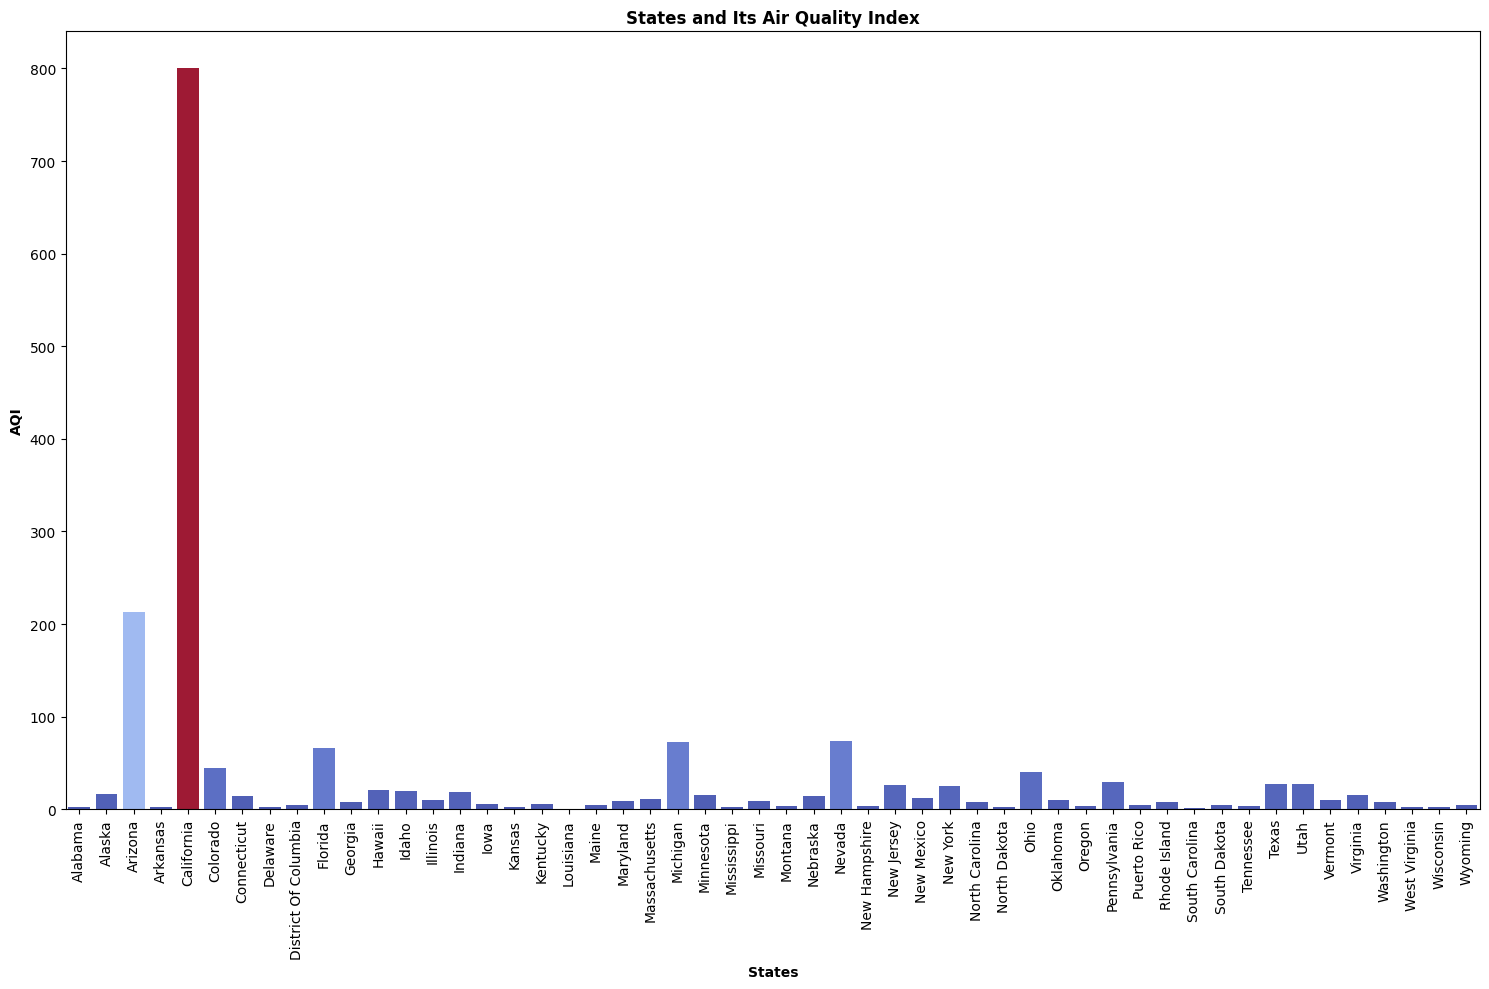

In [97]:
create_barplot(state_and_aqi,0,52,'States','AQI','States and Its Air Quality Index',15,10,'coolwarm')

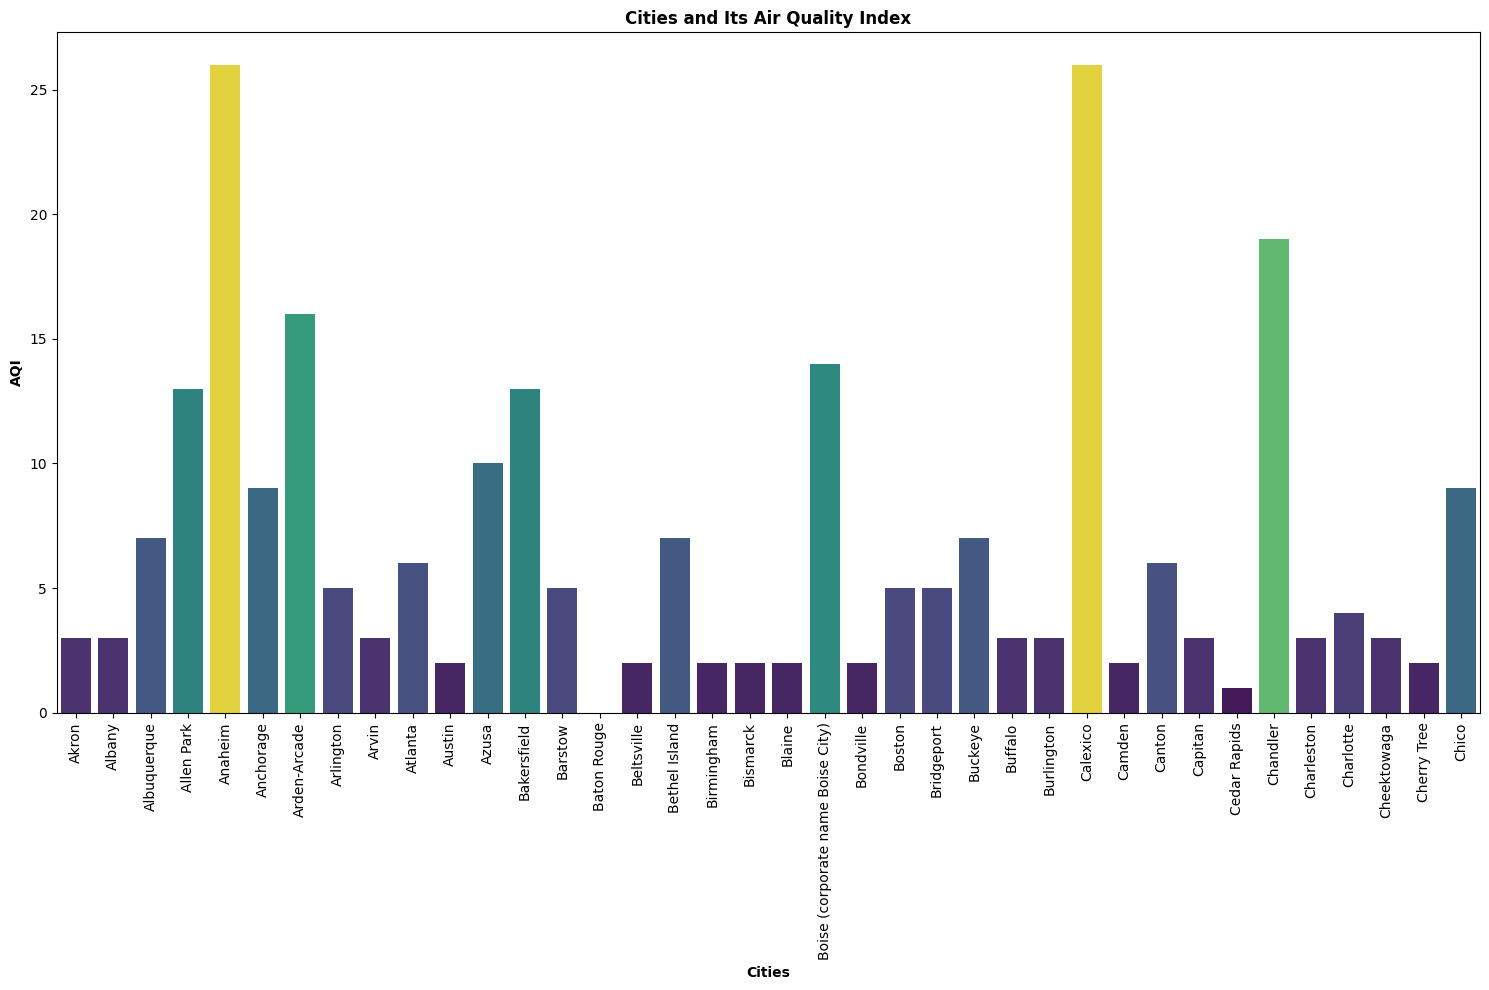

In [7]:
create_barplot(city_and_aqi,0,38,'Cities','AQI','Cities and Its Air Quality Index',15,10,'viridis')

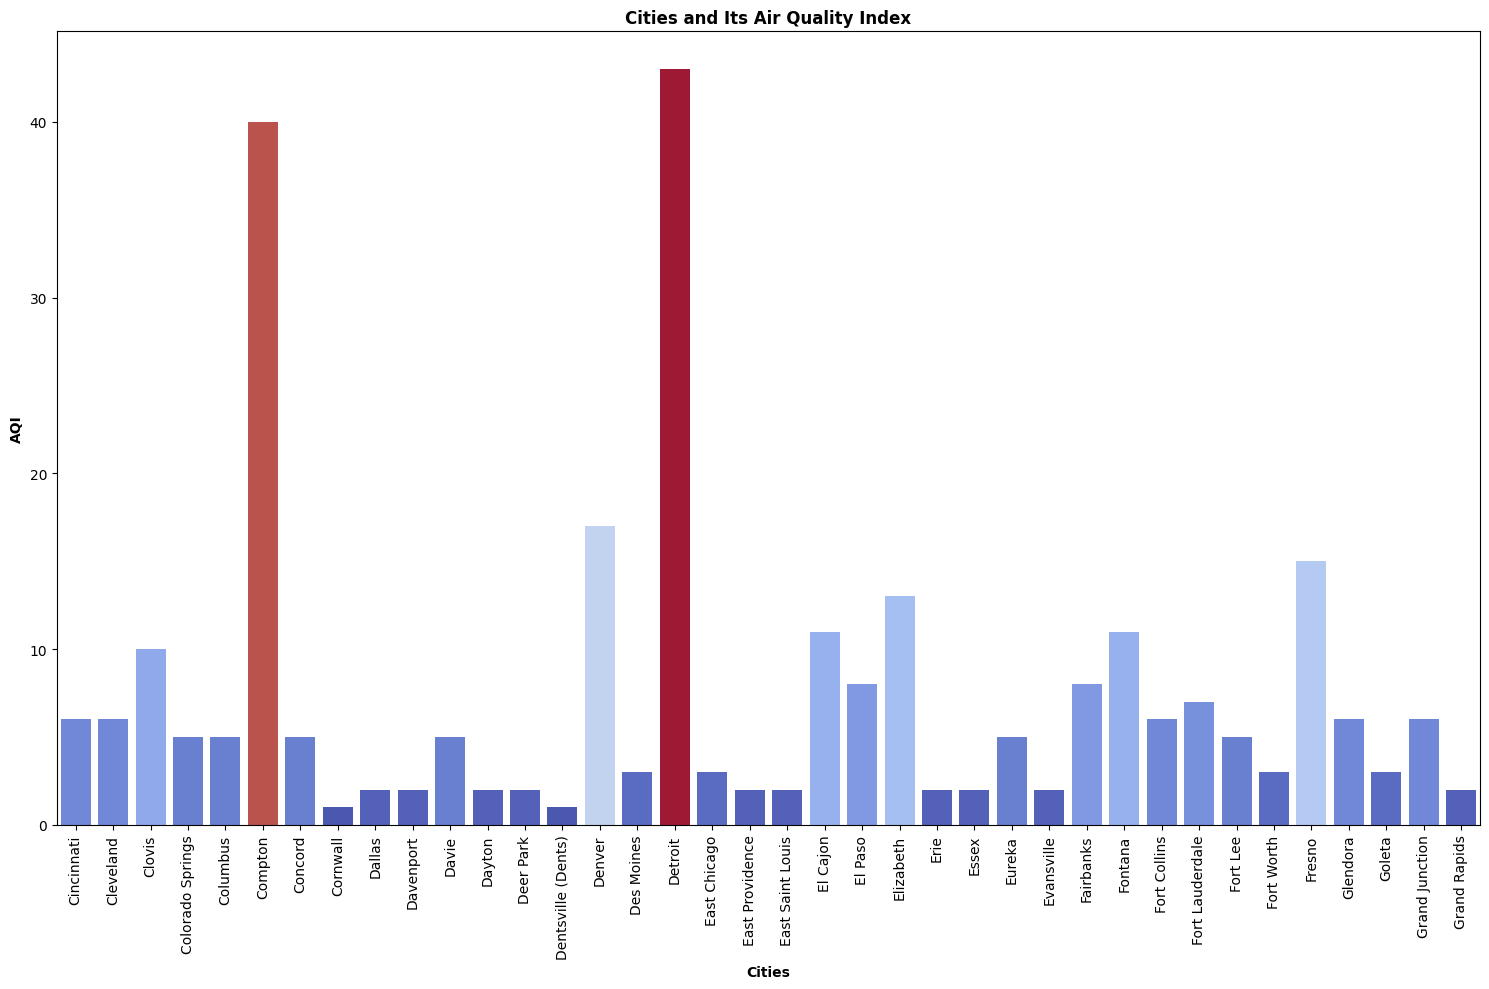

In [8]:
create_barplot(city_and_aqi,38,76,'Cities','AQI','Cities and Its Air Quality Index',15,10,'coolwarm')

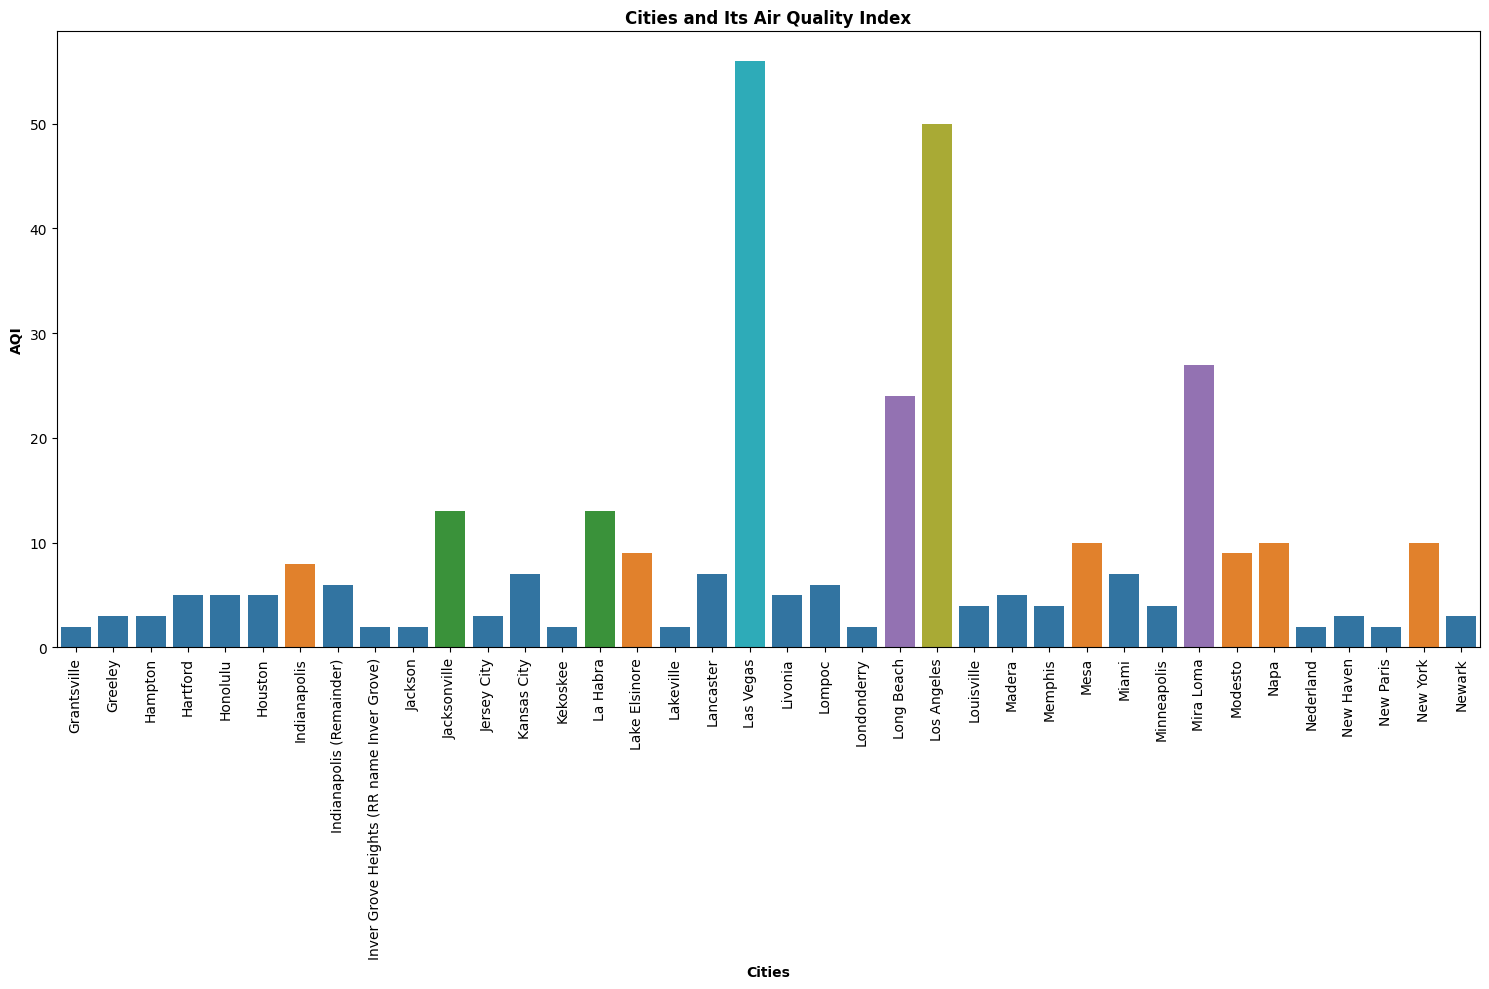

In [9]:
create_barplot(city_and_aqi,76,114,'Cities','AQI','Cities and Its Air Quality Index',15,10,'tab10')

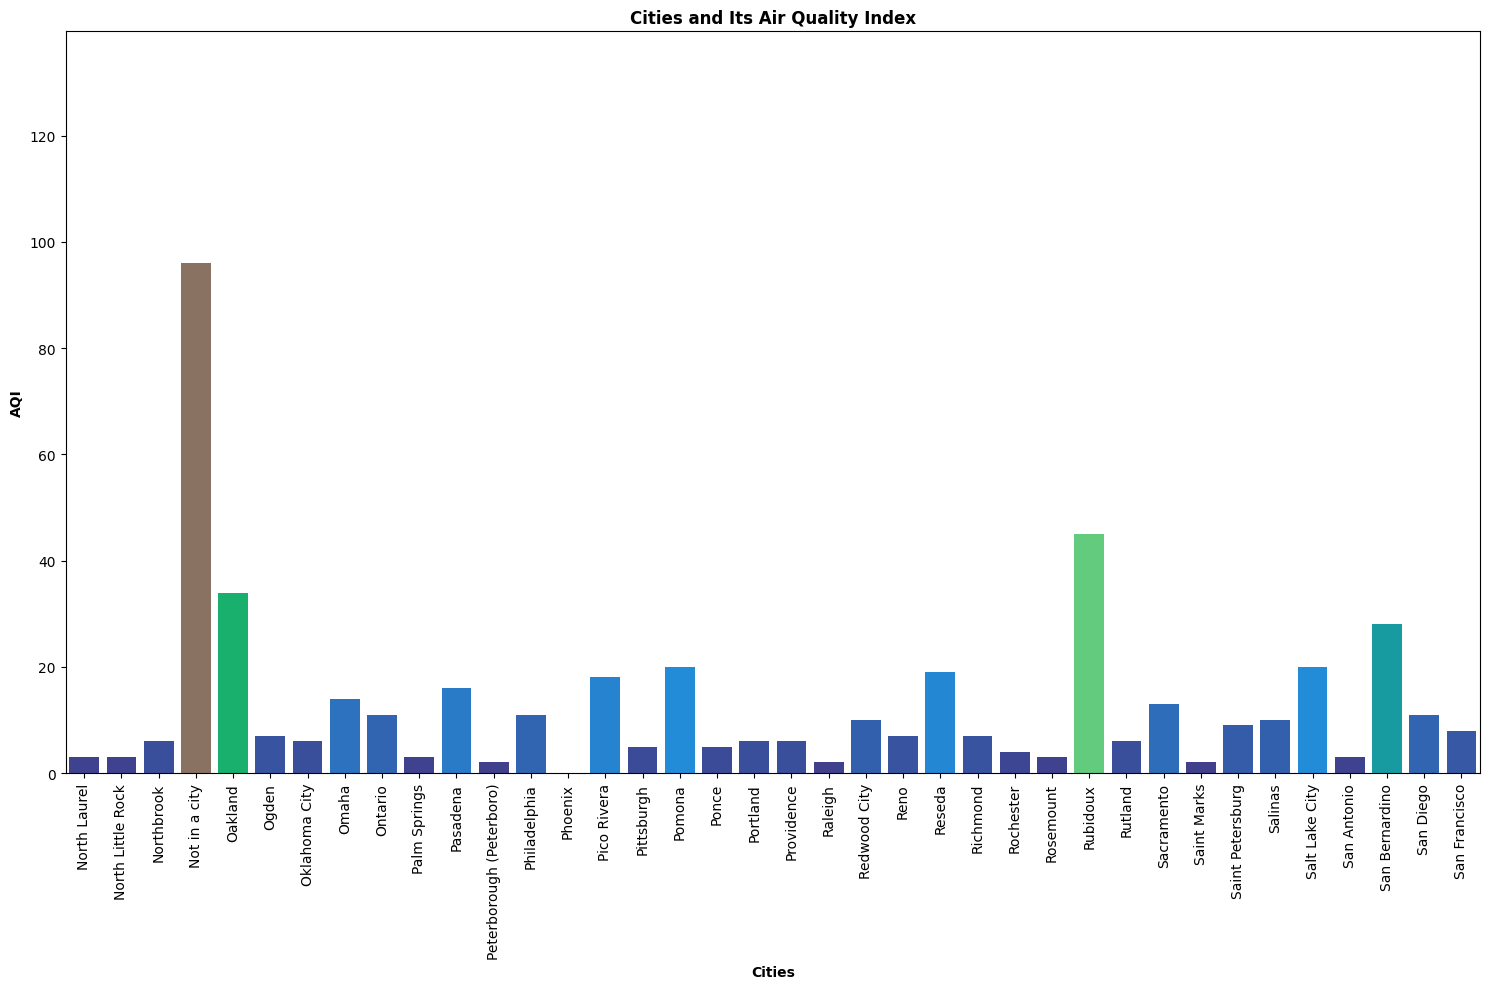

In [10]:
create_barplot(city_and_aqi,114,152,'Cities','AQI','Cities and Its Air Quality Index',15,10,'terrain')

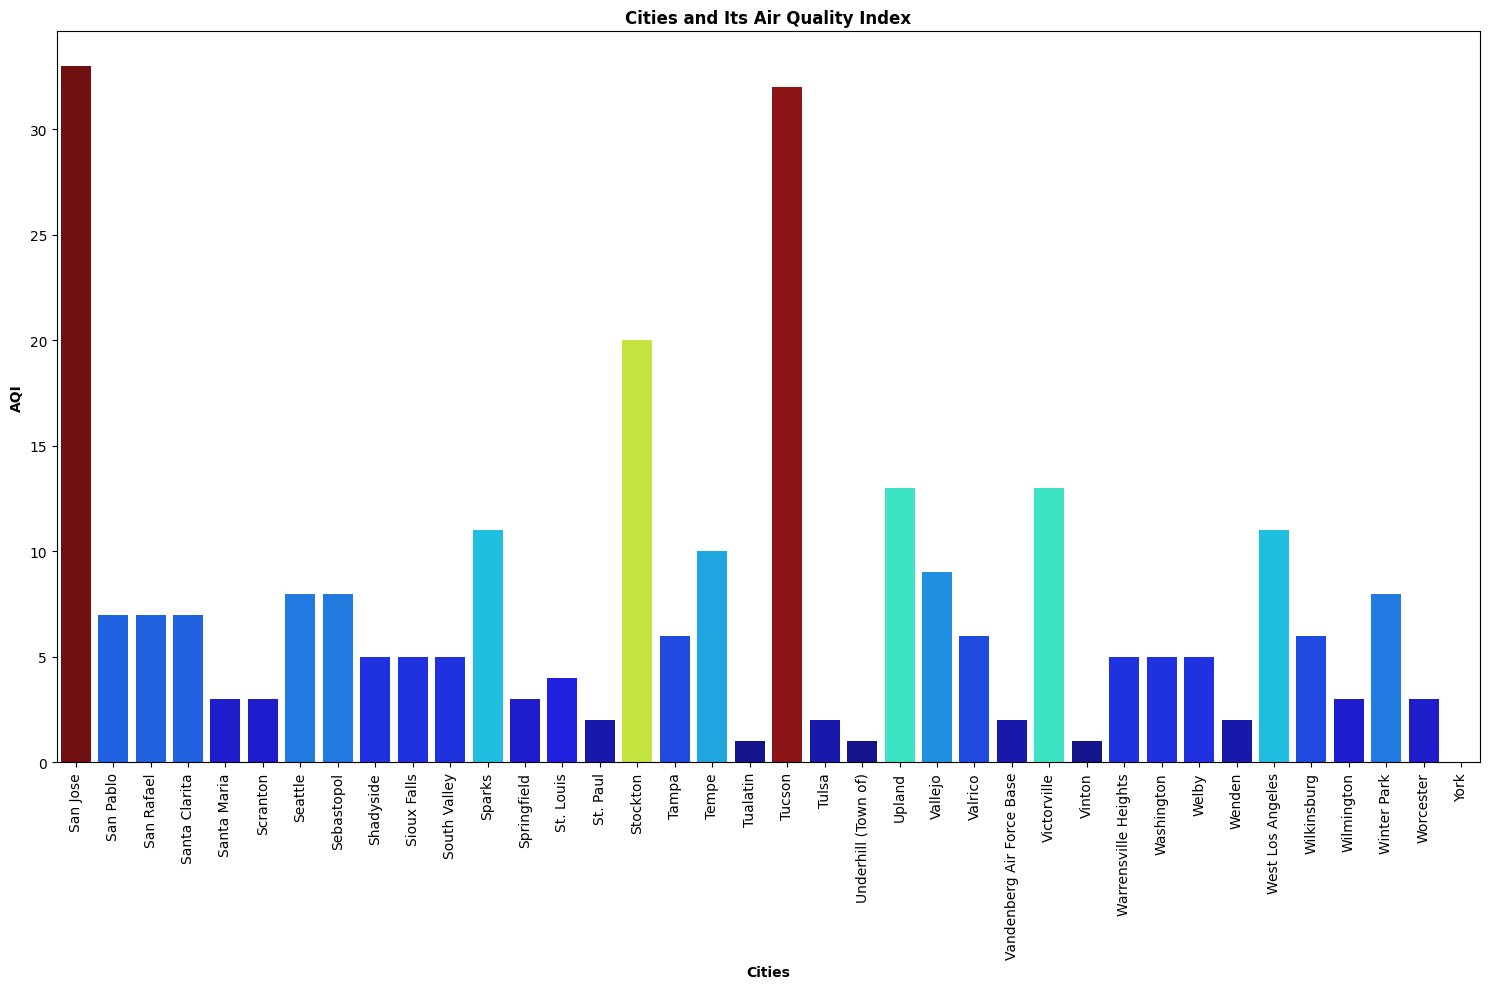

In [11]:
create_barplot(city_and_aqi,152,190,'Cities','AQI','Cities and Its Air Quality Index',15,10,'jet')

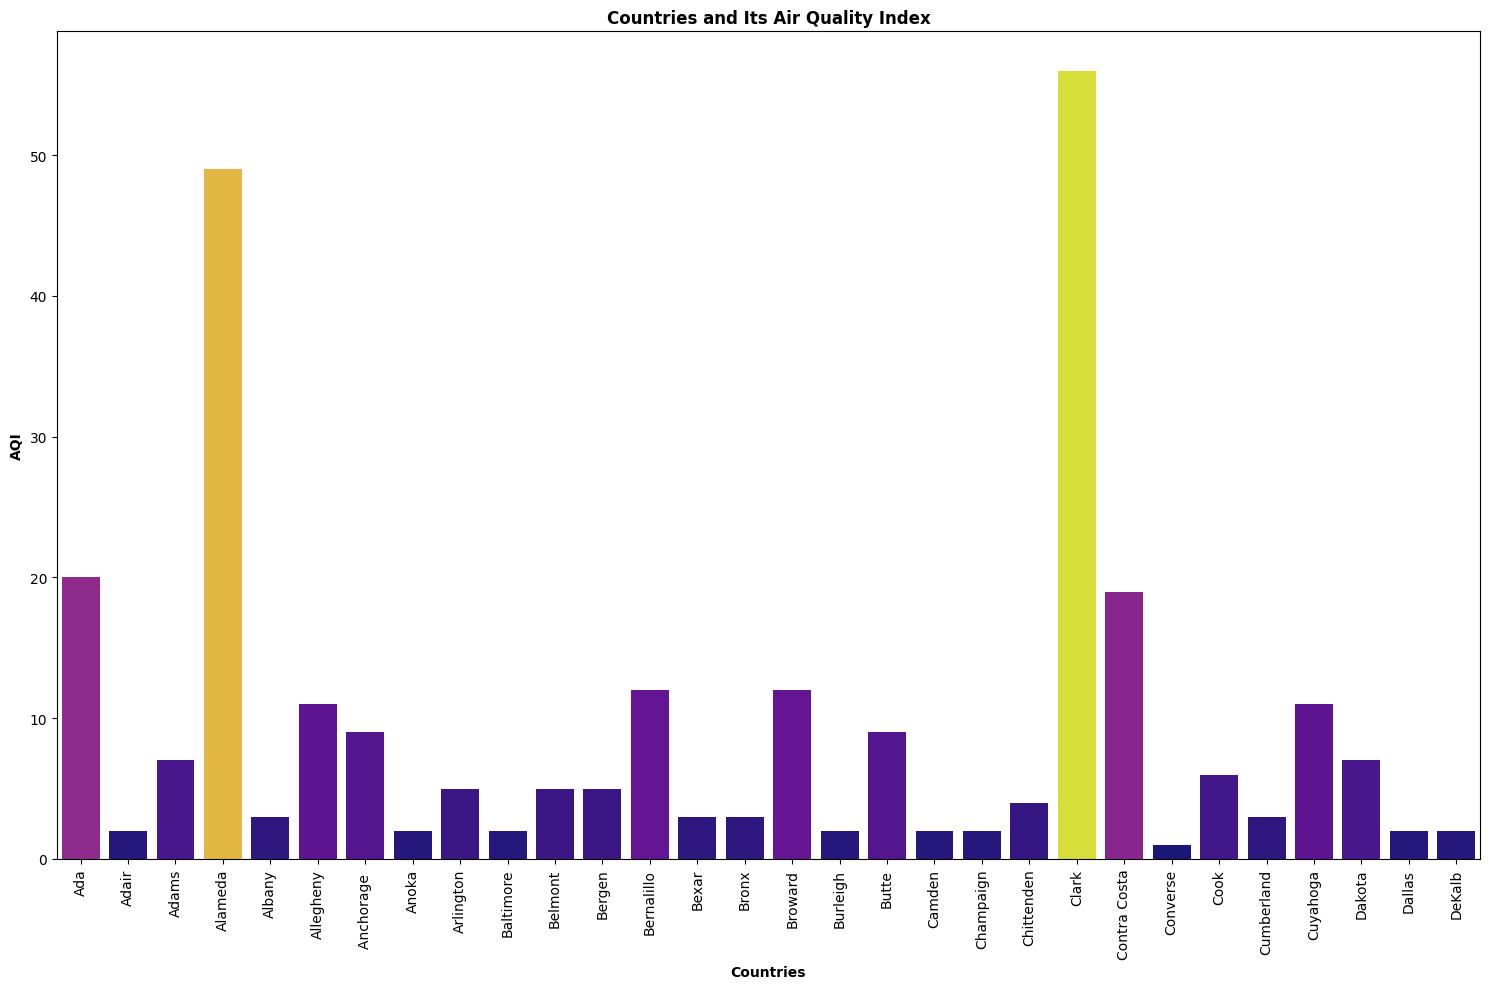

In [12]:
create_barplot(country_and_aqi,0,30,'Countries','AQI','Countries and Its Air Quality Index',15,10,'plasma')

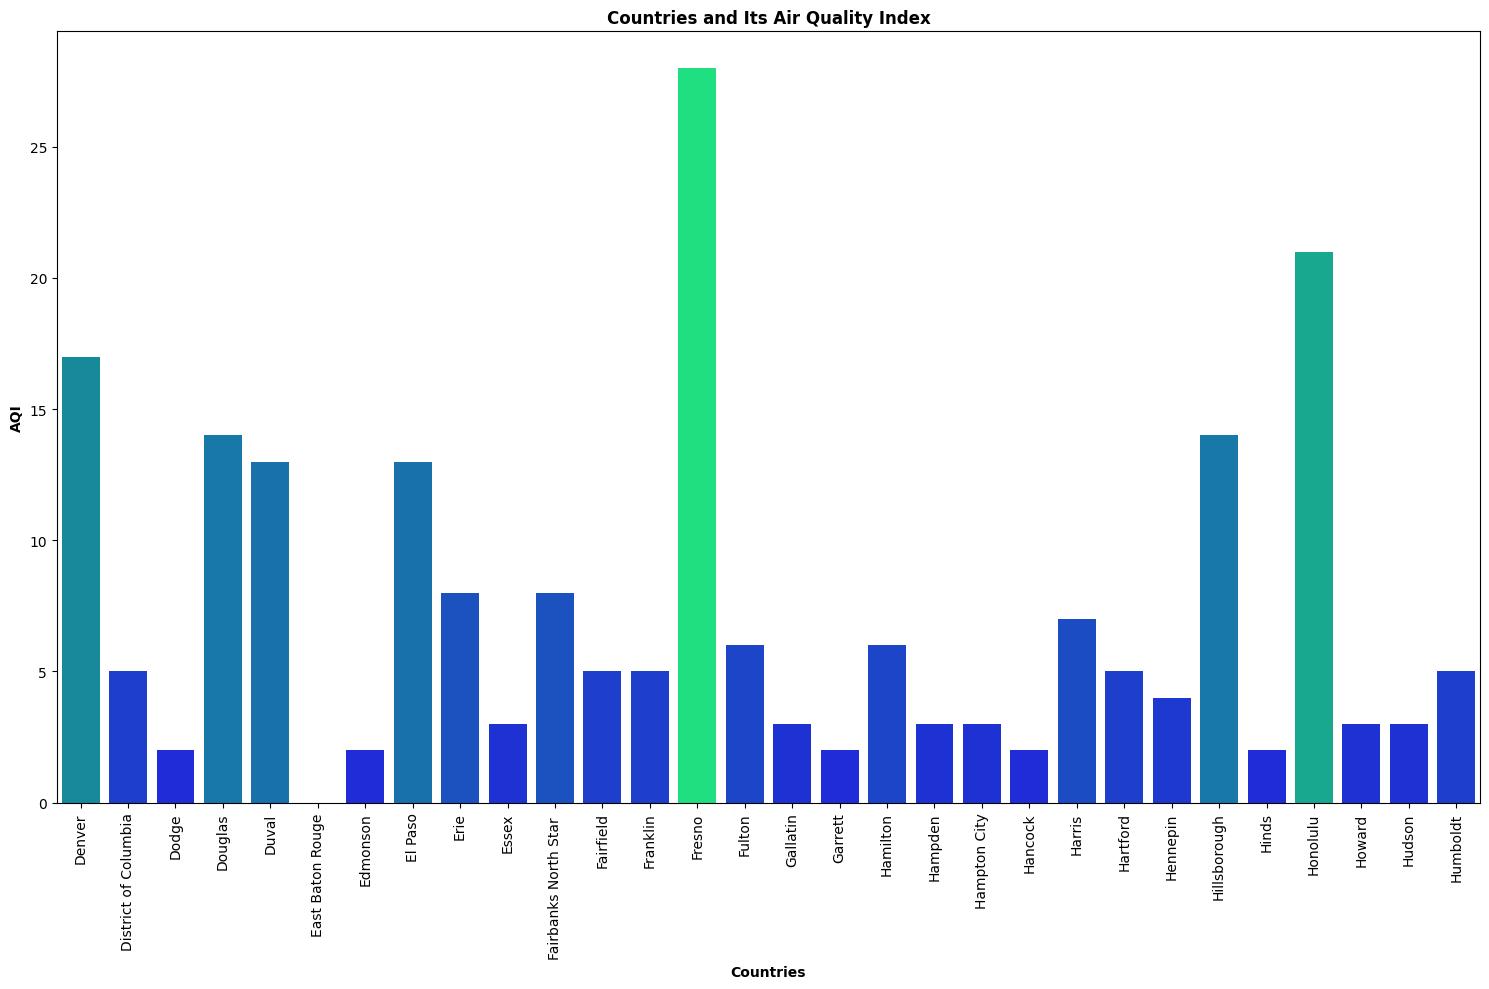

In [13]:
create_barplot(country_and_aqi,30,60,'Countries','AQI','Countries and Its Air Quality Index',15,10,'winter')

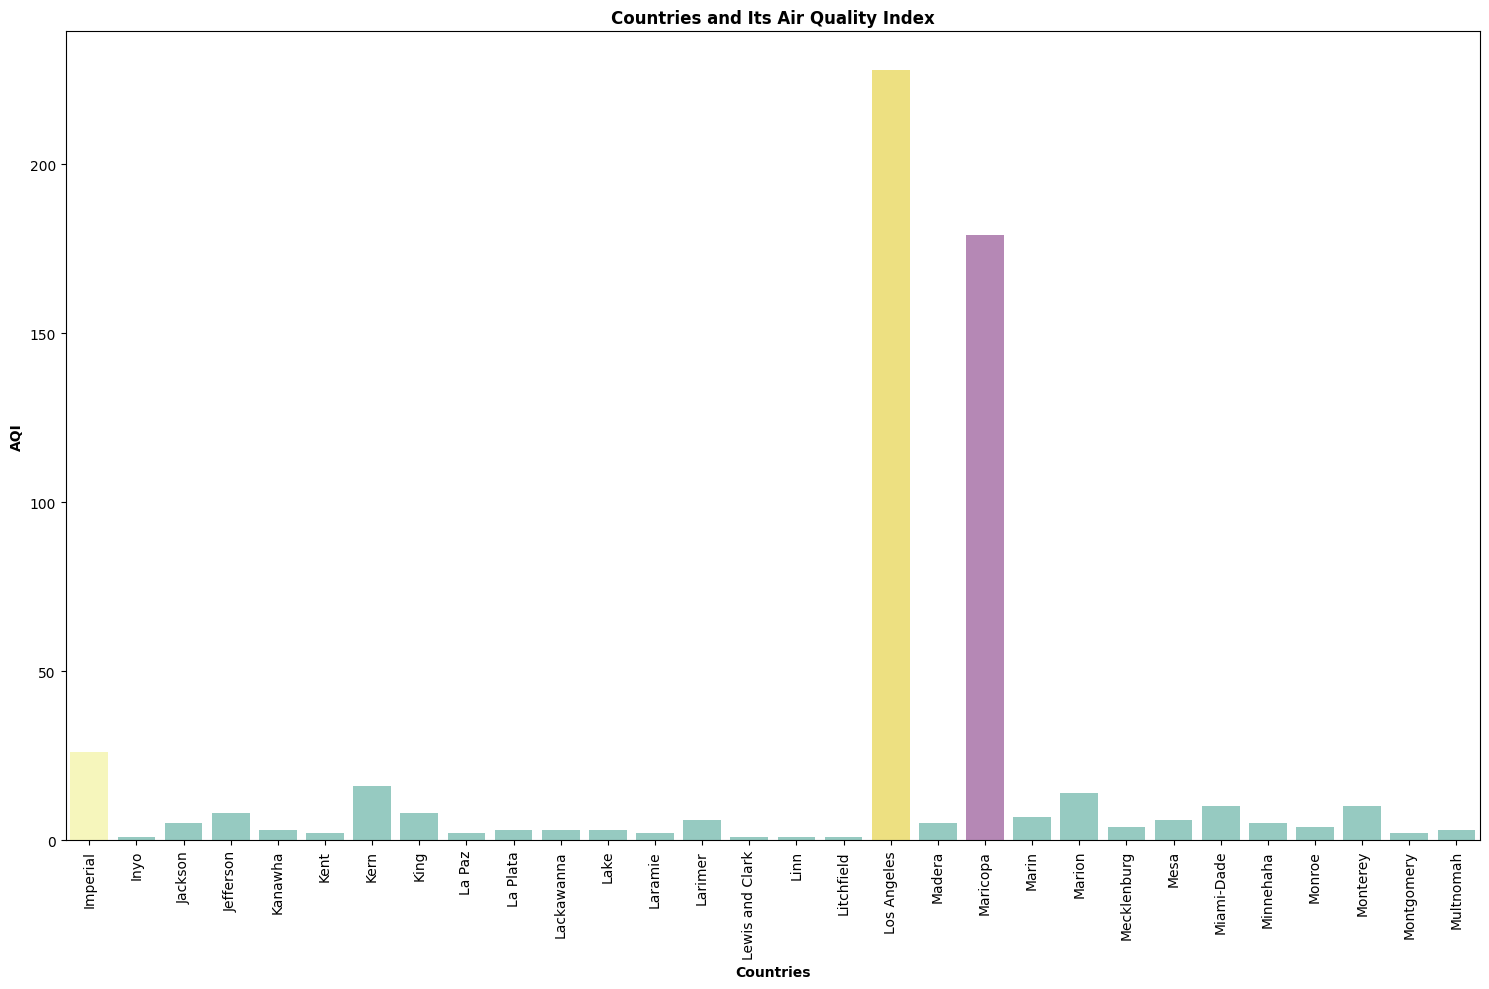

In [14]:
create_barplot(country_and_aqi,60,90,'Countries','AQI','Countries and Its Air Quality Index',15,10,'Set3')

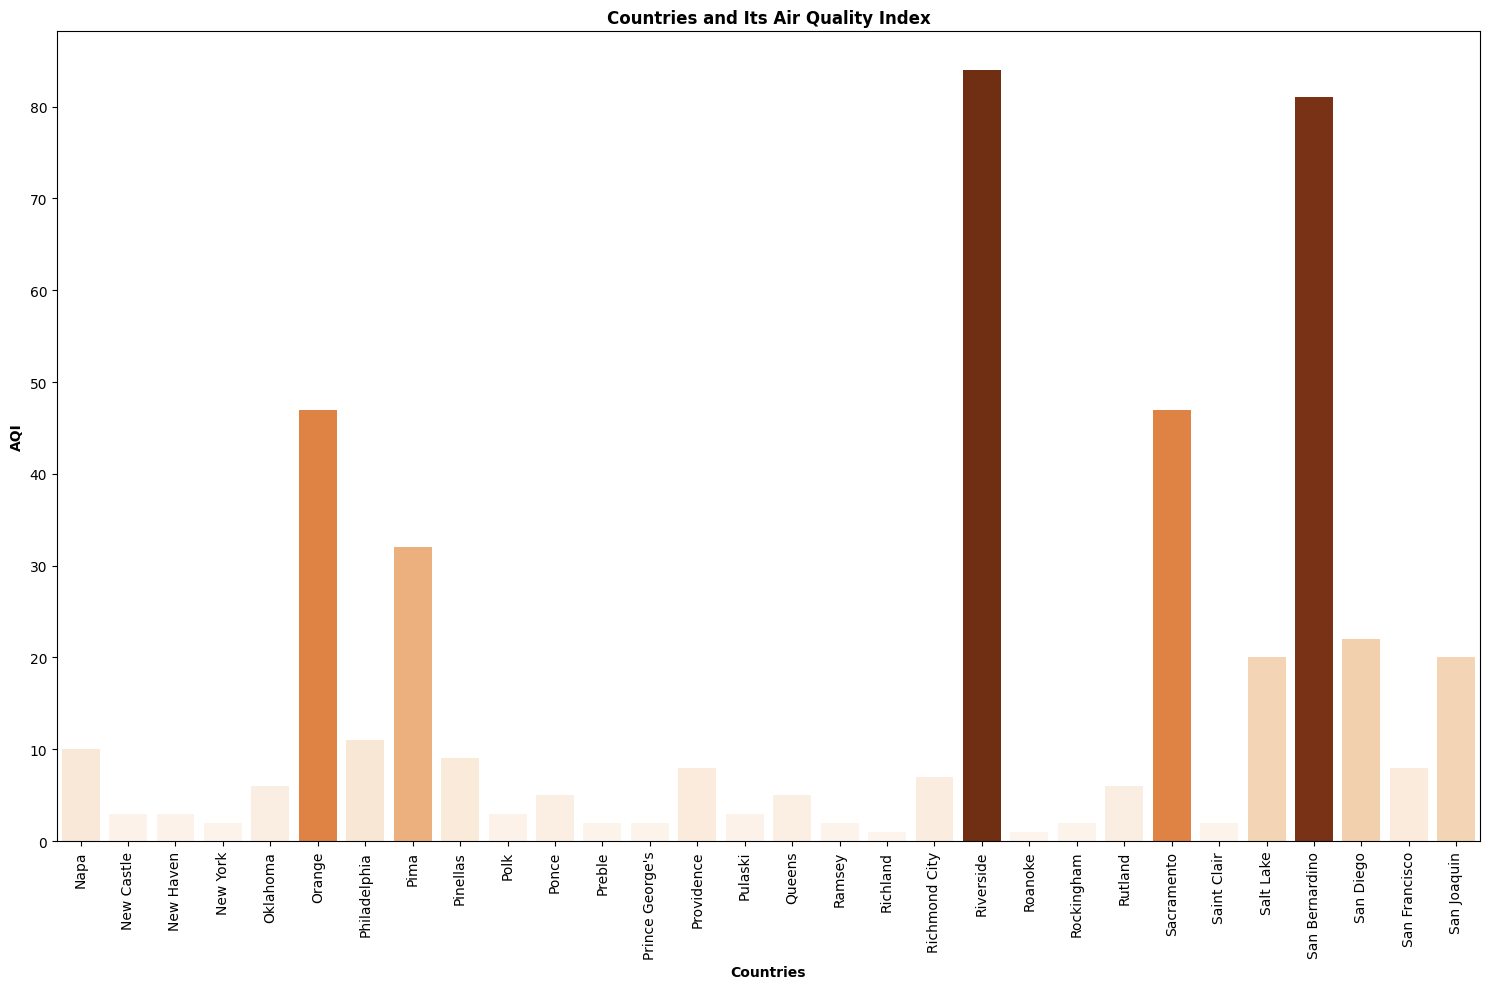

In [15]:
create_barplot(country_and_aqi,90,120,'Countries','AQI','Countries and Its Air Quality Index',15,10,'Oranges')

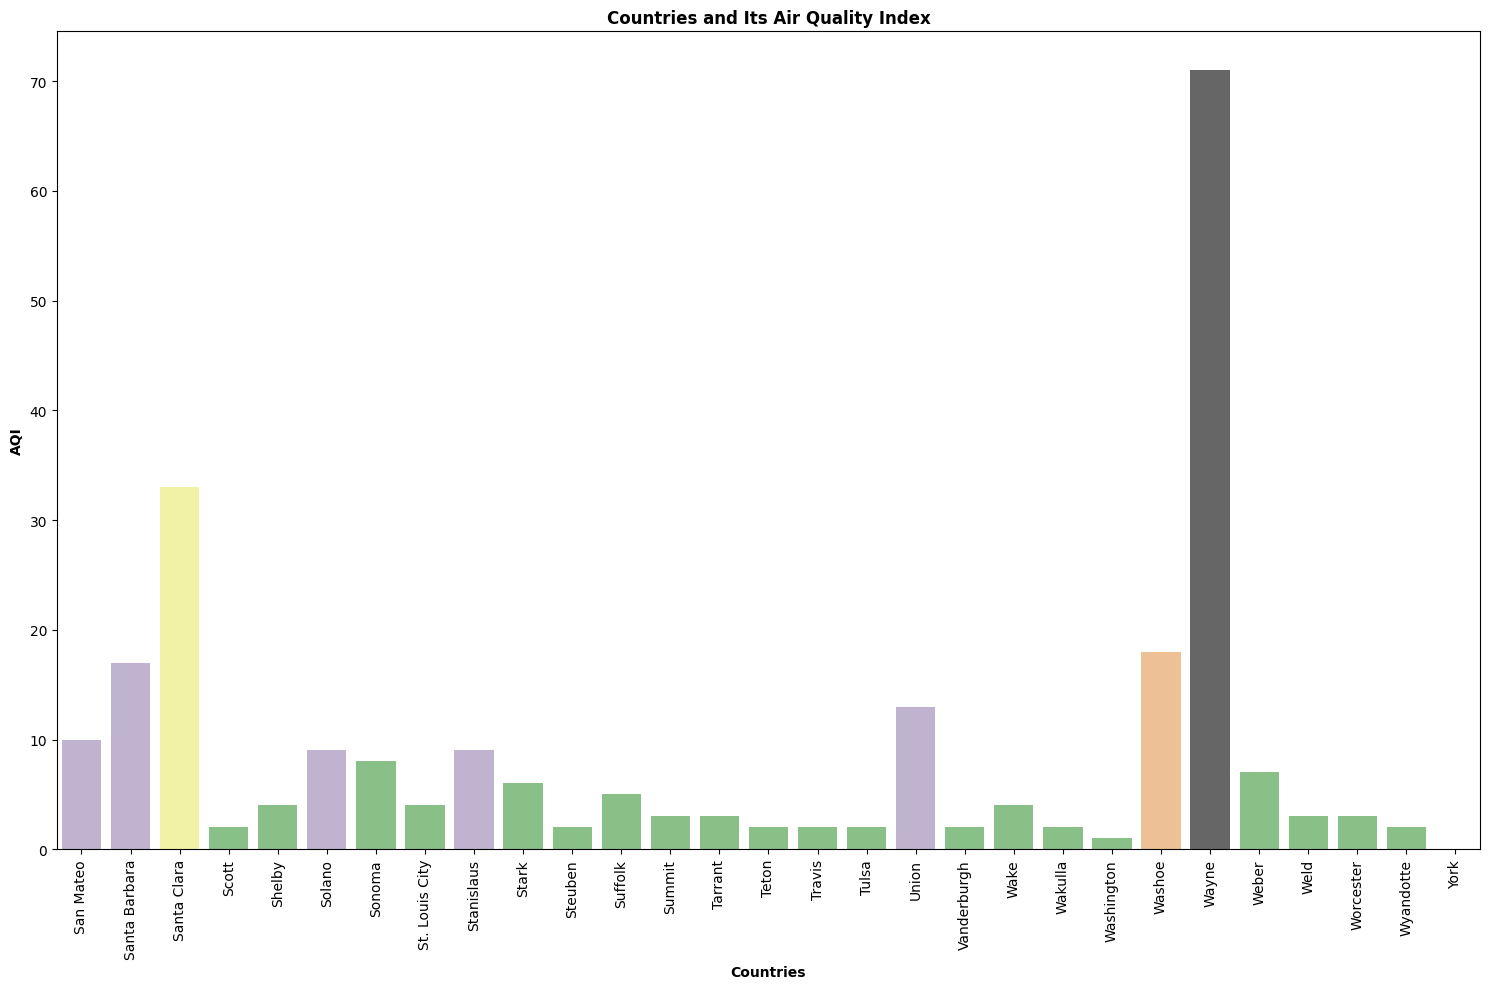

In [16]:
create_barplot(country_and_aqi,120,149,'Countries','AQI','Countries and Its Air Quality Index',15,10,'Accent')

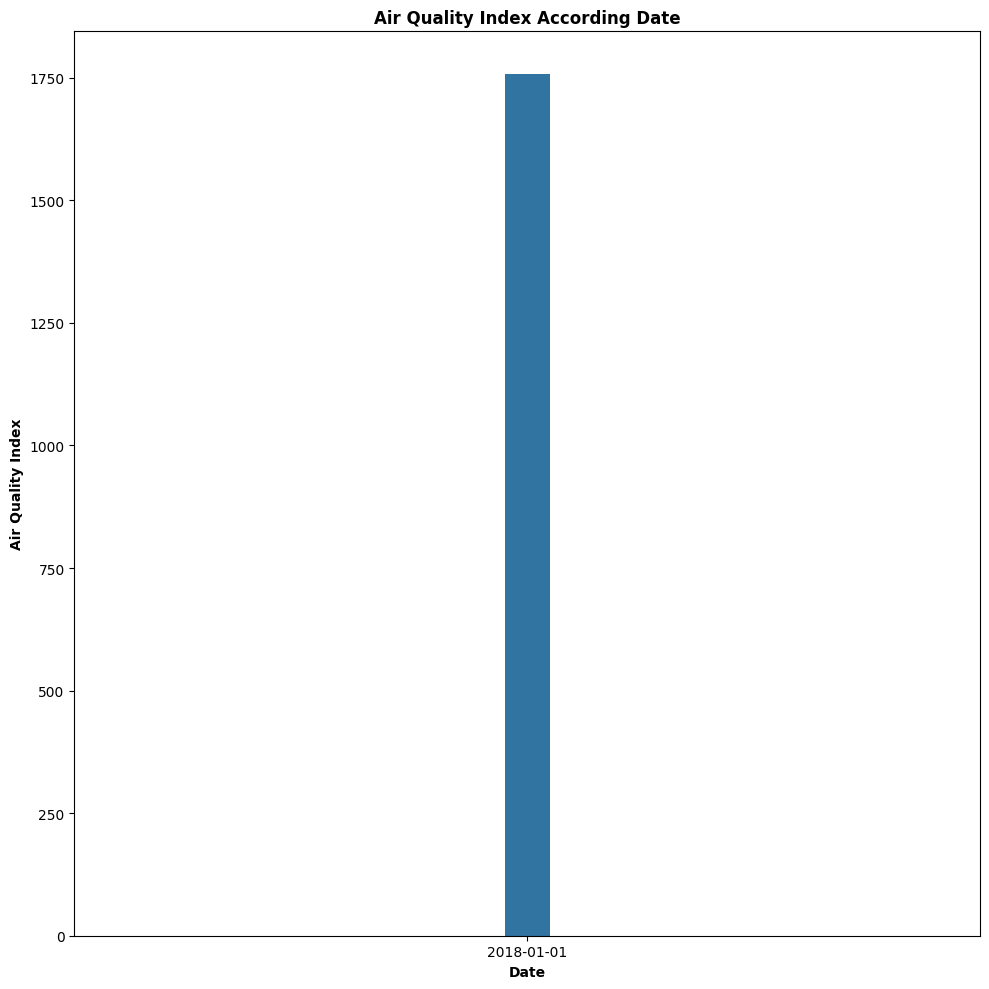

In [45]:
def barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color, hue=subset.index, width=0.05)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.tight_layout()
    plt.show()
barplot(date_and_aqi,0,1,'Date','Air Quality Index','Air Quality Index According Date',10,10,'tab10')

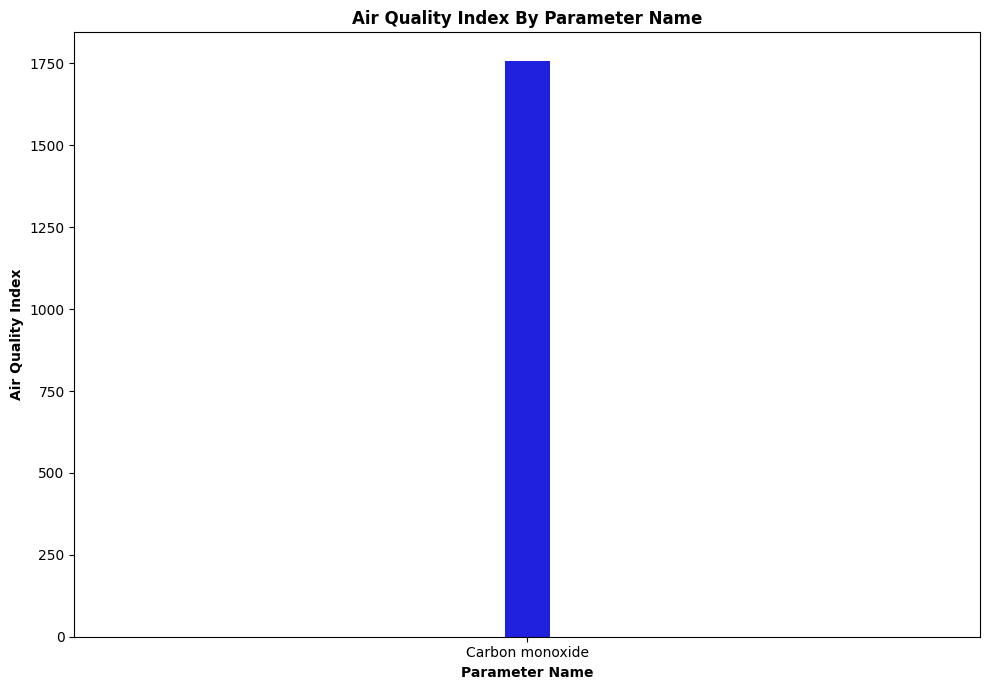

In [82]:
def barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color, hue=subset.index, width=0.05)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.tight_layout()
    plt.show()
barplot(parameter_name_and_aqi,0,1,'Parameter Name','Air Quality Index','Air Quality Index By Parameter Name',10,7,'winter')

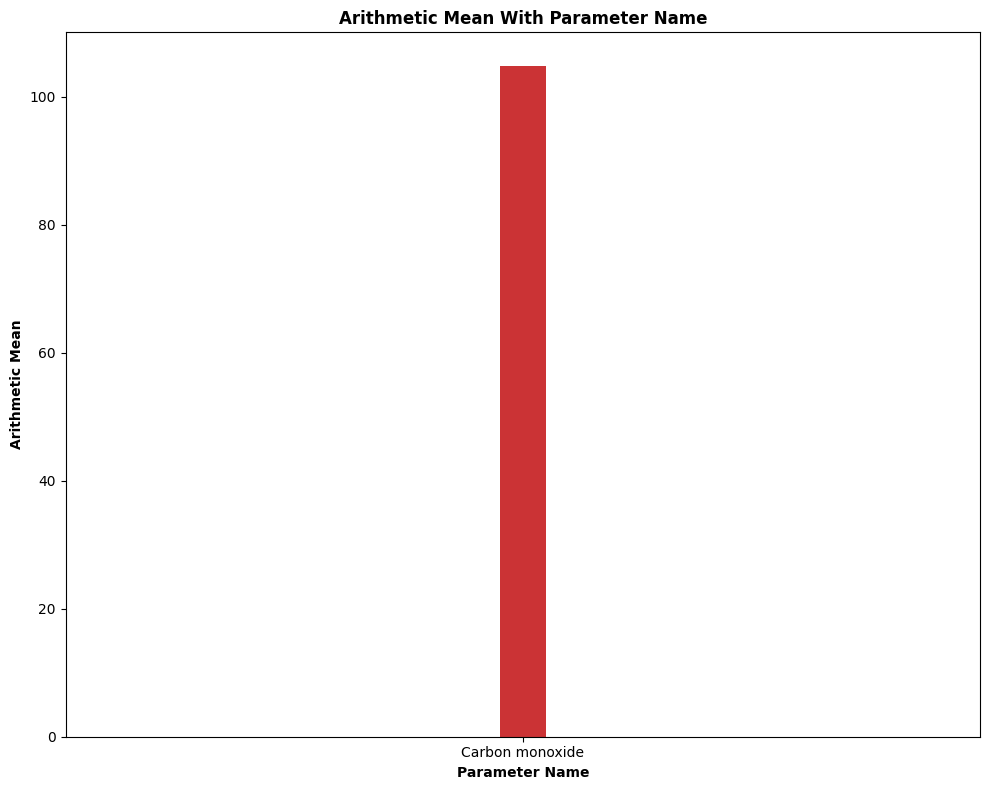

In [80]:
def barplot(data, start, end, xlabel='None', ylabel='None', title='Data', fig_width=20, fig_height=10, colormap='red'):
    """
    Creates a bar plot for the specified subset of the data, with color gradient based on the values.

    Args:
        data (pandas.DataFrame): The dataset containing the data to plot.
        start (int): The starting index for selecting the subset of the data.
        end (int): The ending index for selecting the subset of the data.
        xlabel (str, optional): Label for the x-axis. Default is 'None'.
        ylabel (str, optional): Label for the y-axis. Default is 'None'.
        title (str, optional): Title of the plot. Default is 'Covid Data'.
        fig_width (int, optional): Width of the figure. Default is 20.
        fig_height (int, optional): Height of the figure. Default is 10.
        colormap (str, optional): The colormap to use for coloring the bars. Default is 'red'.

    Returns:
        None: Displays the bar plot.
    """
    subset = data.iloc[start:end]
    plt.figure(figsize=(fig_width, fig_height))
    values = subset.columns[0]
    
    norm = mcolors.Normalize(vmin=subset[values].min(), vmax=subset[values].max())
    cmap = matplotlib.colormaps[colormap]  
    color = [cmap(norm(value)) for value in subset[values]]
    
    sns.barplot(data=subset, x=subset.index, y=subset[values], palette=color, hue=subset.index, width=0.05)
    plt.title(title, fontweight='bold')
    plt.xlabel(xlabel, fontweight='bold')
    plt.ylabel(ylabel, fontweight='bold')
    plt.tight_layout()
    plt.show()
barplot(parameter_name_and_arithmetic_mean,0,1,'Parameter Name','Arithmetic Mean','Arithmetic Mean With Parameter Name',10,8,'Set1')

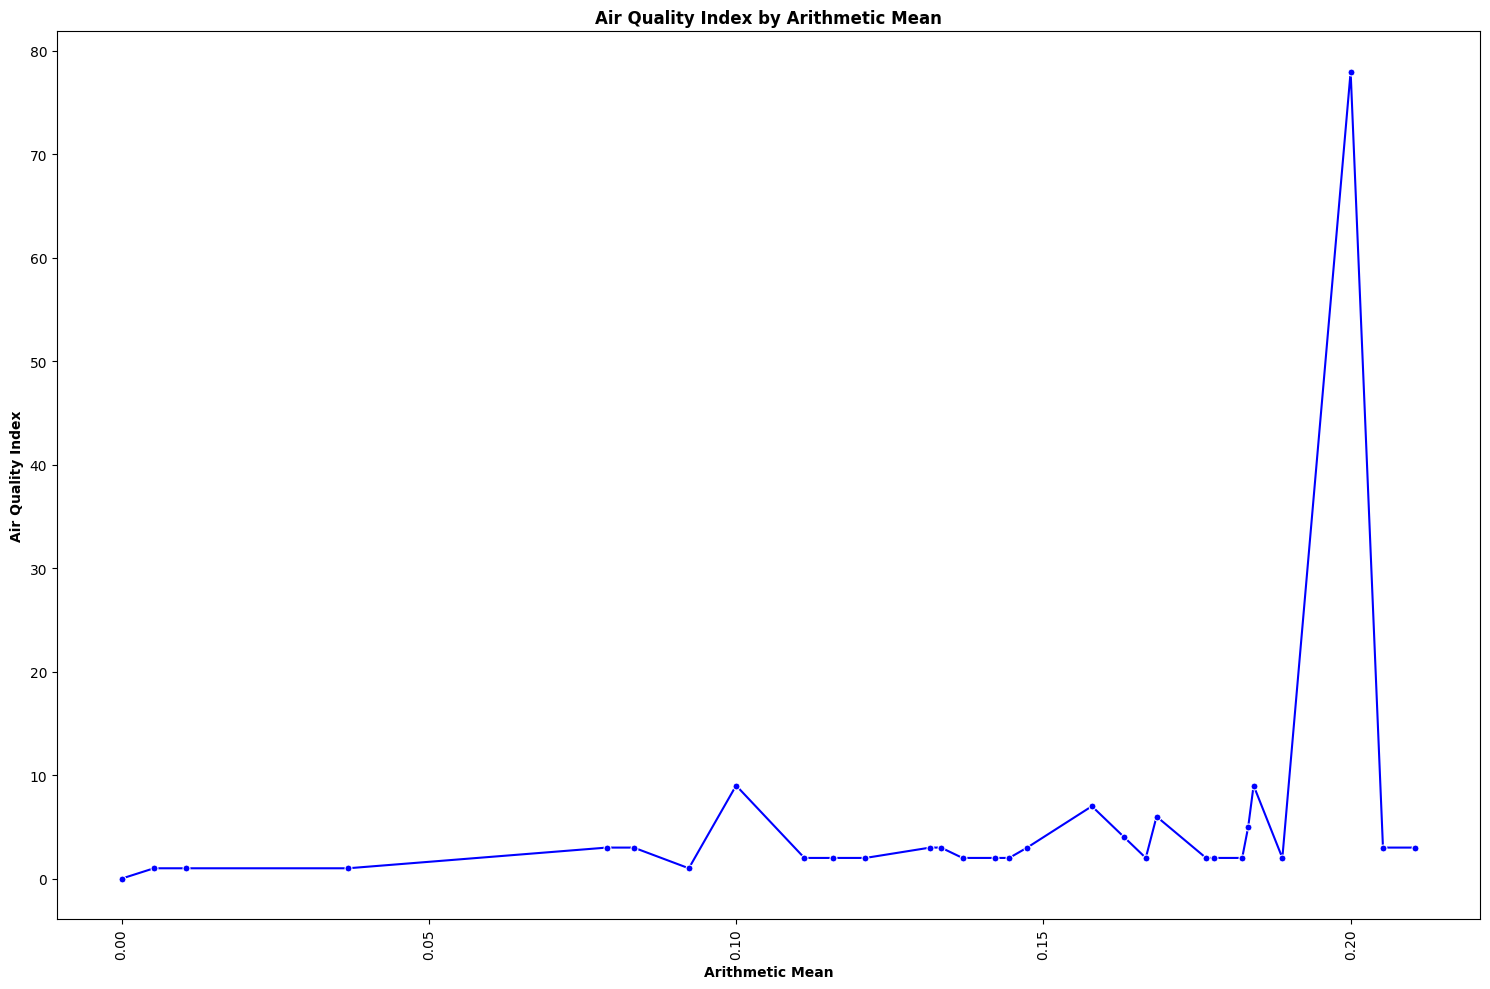

In [94]:
create_lineplot(arithmetic_mean_and_aqi,0,30,'Arithmetic Mean','Air Quality Index','Air Quality Index by Arithmetic Mean',15,10,'blue')